# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [5]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
None


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


- Se observa que en users(usuarios) la columna city(ciudad) cuenta con 469 nulos representando el 11.73%; en la columna churn_date(fecha de abandono), tiene 3534 nulos representando un 88.35%, pero entendiendo es la fecha de abandono, lo cual indica que los usuarios estan activos si esta se encuentra nula.

- En cuanto al dataset usage(uso), la columna date(fecha) tiene 50 nulos representando el 0.13% del total, la columna duration(duración) tiene 22076 nulos representando el 55.19% del total y length con 17896 representando el 44.74% del total. Cabe mencionar que se ve una relación de si se llenan o no dependiendo de la columna type(tipo) pero se confirmará posteriormente.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` esta columna es de identificador de usuario, por eso cumple con lo que se espera que su desviación estándar es muy alta y el número inicial es 10000 y el máximo es 13999 que cumplen los 4000 registros que hay.
- La columna `age`,  se observa que la dispersión es alta sin embargo se ve que se encuentran sentinels que desvían demasiado los valores (-999), se propone mas trabajo de limpieza para disipar esas disperciones. 

In [15]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son columnas de identificadores o consecutivos y cumplen con esas características por lo cual estas columnas no son relevantes para el análisis.
- Las columnas duration y length son columnas de consumo y se comportan de acuerdo a ello habiendo una desviación tendida a la derecha por tanto los minutos como la longitud de los mensajes enviados, estas dos columnas se tratarán más aprofundidad posteriormente.

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())
print(users["city"].value_counts())
print(users[users["city"]=="?"])

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
      user_id first_name last_name  age city                       reg_date  \
1       10001      Mateo    Torres   53    ?  2022-01-01 06:34:17.914478619   
83      10083    Mariana    Garcia   50    ?  2022-01-23 17:26:46.901725431   
160     10160       Luis    Torres   29    ?  2022-02-13 19:27:46.316579145   
161     10161       Luis     Gomez   22    ?  2022-02-14 02:02:04.231057764   
186     10186      Mateo    Torres   28    ?  2022-02-20 22:19:32.093023256   
...       ...        ...       ...  ...  ...                            ...   
3882    13882     Carlos    Torres   35    ?  2024-11-28 23:07:04.006001504   
3889    13889     Carlos     Lopez   77    ?  2024-11-30 21:07:09.407351840   
3901    13901    Mariana     Lopez   

- La columna `city` se tiene que quitar el sentinel "?" ya que representa el 2.4% del total de los registros, también se observa que no es dependiente de otra de las columnas en particular evitando sesgo.
- La columna `plan` se observa que esta columna esta completa y tiene los dos unicos planes con los que se cuentan.

In [17]:
# explorar columna categórica de usage
print(usage['type'].describe())
print(usage['type'].value_counts())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
text    22092
call    17908
Name: type, dtype: int64


- La columna `type`se observa que esta columna esta completa y lista para el análisis ya que cuenta con solo dos valores que son text y call.


---
✍️ **Comentario**: En general los registros están completos hay que realizar un poco de trabajo de limpieza por los sentinels y los nulos pero es todo muy claro. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En la columna de city en ella encontré a "?" como sentinel.
- ¿Qué acción tomarías? Observando que el número de registros con este sentinel de 96; que representa el 2.4% de todos los registros y que además no es dependiente de alguna columna y que no se puede reconstruir la columna para esos casos se puede eliminar los registros que lo contengan.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = "coerce", utc = True)

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce", utc = True)

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se encuentra en la columna datos de años que no corresponden a los datos que se tienen a lo cual se puede ajustar solo al año que se necesita que es 2024 se pacotará. 

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, se encuentra una homogeneidad en los datos, se tomarán completos los datos.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios

print(users['city'].describe())
print(users['city'].value_counts())


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [24]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].dt.year.replace(2026, pd.NA)

# Verificar cambios
print(users['reg_date'].describe())
print(users['reg_date'].value_counts())

count     3960
unique       3
top       2024
freq      1330
Name: reg_date, dtype: int64
2024    1330
2023    1316
2022    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[['duration']][usage['type'] == 'call'].isna().sum())

duration    0
dtype: int64


In [26]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[['length']][usage['type'] == 'text'].isna().sum())

length    0
dtype: int64


- Aquí se observa que al consultar la columna duration con el type 'call', muestra que no existen nulos, y a su vez si se consulta la columna length con el type 'text', tampoco existen nulos, lo cual indica que es la columna type variante que se llene una u otra dependiendo de la funcionalidad, lo cual es normal en tablas operativas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id')['duration','length','is_text','is_call']\
    .sum()\
    .rename(columns={"duration":"cant_minutos_llamada","length":"cant_longitud_mensajes","is_text":"cant_mensajes","is_call":"cant_llamadas"})\
    .reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_minutos_llamada,cant_longitud_mensajes,cant_mensajes,cant_llamadas
0,10000,23.70,258.0,7,3
1,10001,33.18,226.0,5,10
2,10002,10.74,225.0,5,2


In [28]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_minutos_llamada,cant_longitud_mensajes,cant_mensajes,cant_llamadas
0,10000,23.70,258.0,7,3
1,10001,33.18,226.0,5,10
2,10002,10.74,225.0,5,2


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on = ['user_id'], how = 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,cant_longitud_mensajes,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,23.70,258.0,7.0,3.0
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,33.18,226.0,5.0,10.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,10.74,225.0,5.0,2.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,8.99,530.0,11.0,3.0
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,8.01,229.0,4.0,3.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_minutos_llamada,cant_longitud_mensajes,cant_mensajes,cant_llamadas
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,23.317054,288.128032,5.524381,4.478120
std,1154.844867,17.690408,18.168095,180.906841,2.358416,2.144238
min,10000.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,11.120000,184.000000,4.000000,3.000000
50%,11999.500000,47.000000,19.780000,268.000000,5.000000,4.000000
75%,12999.250000,63.000000,31.415000,361.000000,7.000000,6.000000
max,13999.000000,79.000000,155.690000,2028.000000,17.000000,15.000000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

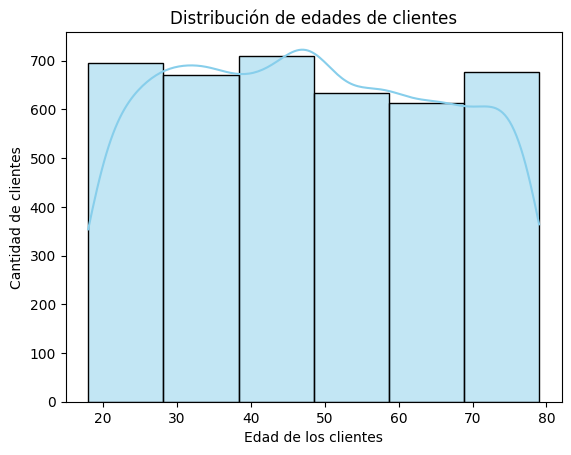

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile["age"], bins = 6, color = 'skyblue', kde = True)
plt.xlabel('Edad de los clientes')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de edades de clientes')
plt.show()

💡Insights: Se observa que las edades pico de clientes esta entre 40 y 50 años acercandose mucho de entre 20 y 30 años; y entre 70 y 80 años.
- Distribución homogenea en general pero tendiendo a la normal triple, lo cual indica que el numero de clientes se congrega en tres picos entre 40 y 50 años, entre 20 y 30 años y entre 70 y 80 años.

# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile["cant_mensajes"], bins = 17, color = 'skyblue', kde = True)
plt.xlabel('Cantidad de mensajes enviados')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de mensajes por clientes')
plt.show()

💡Insights: Se observa una distribución homogenea normal teniendo pico de entre 3 y 7 mensajes en el periodo semando mas de 20 clientes.

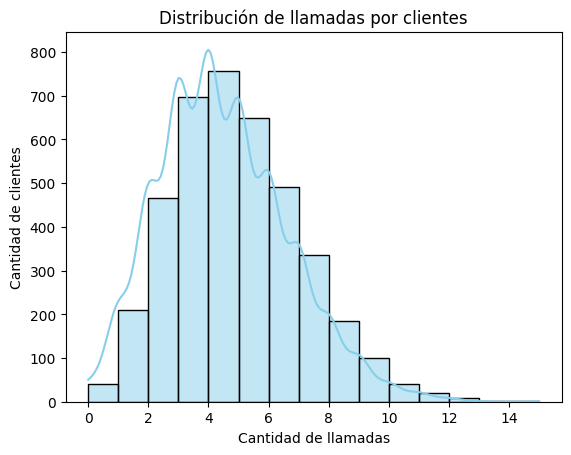

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile["cant_llamadas"], bins = 15, color = 'skyblue', kde = True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de llamadas por clientes')
plt.show()

💡Insights: Se tiene que mas de 2000 clientes realizan entre 3 y 6 llamadas
- Distribución homogenea normal tendiendo un poco a la derecha.

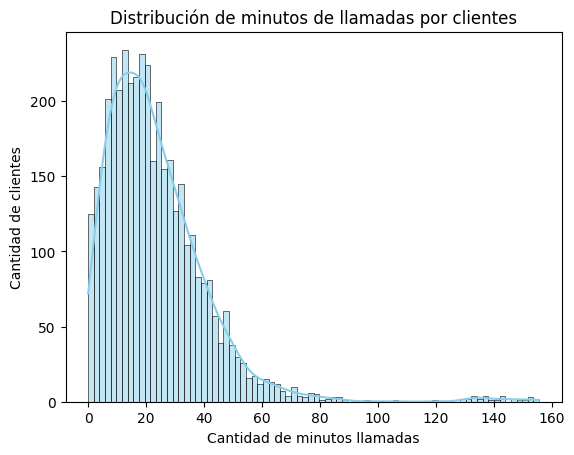

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile["cant_minutos_llamada"], bins = 80, color = 'skyblue', kde = True)
plt.xlabel('Cantidad de minutos llamadas')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de minutos de llamadas por clientes')
plt.show()

💡Insights: Se observa que hay un pico muy importante alrededor de los 20 minutos pero se ve tambien insidencia de algonos clientes a los 130 y 150 minutos que podrían representar una oportunidad.
- Es una media distribución normal tendido a la derecha que implica compras con una disminución desde los 20 minutos hasta los 150 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

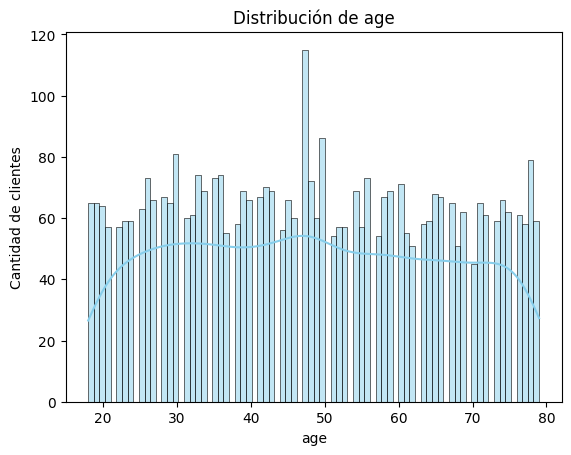

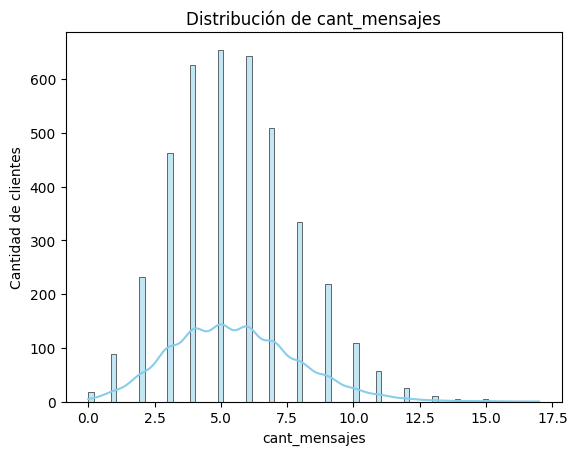

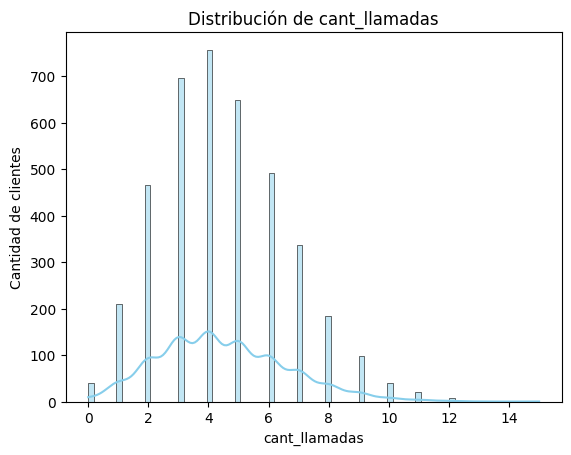

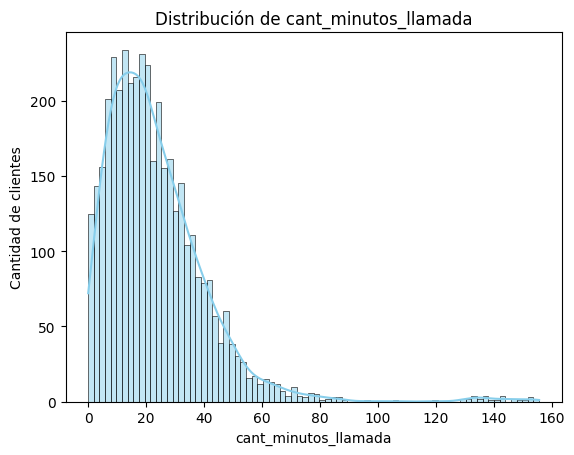

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.histplot(user_profile[col], bins = 80, color = 'skyblue', kde = True)
    plt.ylabel('Cantidad de clientes')
    plt.title('Distribución de '+col)
    plt.show()

💡Insights: Se encuentra que hay mas usuarios de entre 47 y 48 años, que en promedio tienen 5 mensajes y 4 llamadas con entre 15 y 25 minutos
- Age: No presenta outliers todo esta y corta dentro de un rango definido.
- cant_mensajes: Si cuenta con outliers pero en realidad son pocos datos
- cant_llamadas: Si cuenta con outliers pero en realidad son pocos datos
- cant_minutos_llamada: Si cuenta con outliers y deben ser varios por la gráfica.

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Debe tenerlos porque el Q3 esta muy retirado del max y esto indica que debe de tener outliers.
- cant_llamadas: mantener o no outliers, porqué? Debe tenerlos porque el Q3 esta muy retirado del max y esto indica que debe de tener outliers.
- cant_minutos_llamada: mantener o no outliers, porqué? Debe tenerlos porque el Q3 esta muy retirado del max y esto indica que debe de tener outliers.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def clasif_usu_grupo(row):
    num_llamadas = row['cant_llamadas']
    num_mensajes = row['cant_mensajes']

    # Segmentación
    if num_llamadas < 5 and num_mensajes < 5:
        return "Bajo uso"
    elif num_llamadas < 10 and num_mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

#Se aplica la función
user_profile['grupo_uso'] = user_profile.apply(clasif_usu_grupo, axis = 1)

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,cant_longitud_mensajes,cant_mensajes,cant_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,23.70,258.0,7.0,3.0,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,33.18,226.0,5.0,10.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,10.74,225.0,5.0,2.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,8.99,530.0,11.0,3.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,8.01,229.0,4.0,3.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
def clasif_usu_edad(row):
    edad = row['age']
    
    # Segmentación
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

#Se aplica la función
user_profile['grupo_edad'] = user_profile.apply(clasif_usu_edad, axis = 1)

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_minutos_llamada,cant_longitud_mensajes,cant_mensajes,cant_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,23.70,258.0,7.0,3.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,33.18,226.0,5.0,10.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,10.74,225.0,5.0,2.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,8.99,530.0,11.0,3.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,8.01,229.0,4.0,3.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

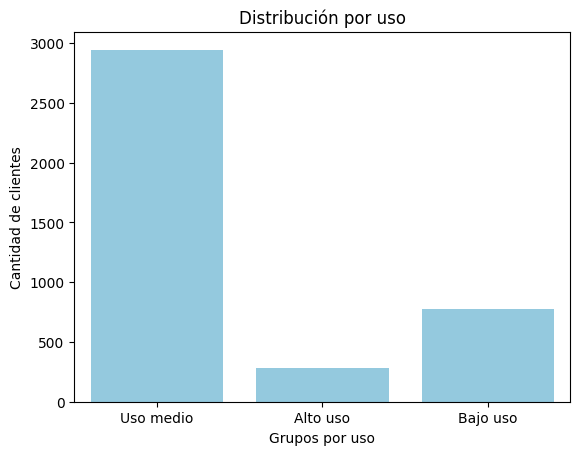

In [42]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile, x = 'grupo_uso', color='skyblue')
plt.xlabel('Grupos por uso')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución por uso')
plt.show()

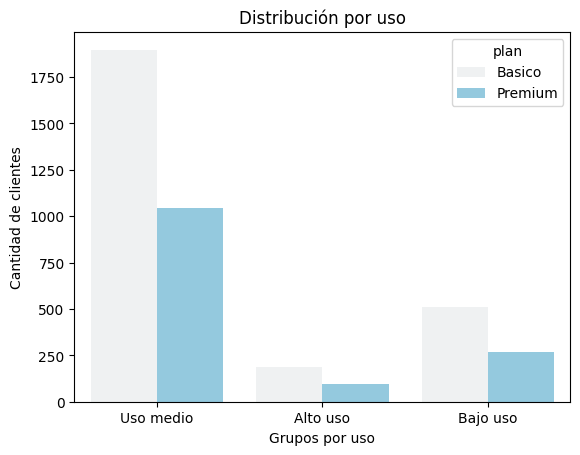

In [48]:
sns.countplot(data = user_profile, x = 'grupo_uso', hue = "plan", color='skyblue')
plt.xlabel('Grupos por uso')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución por uso')
plt.show()

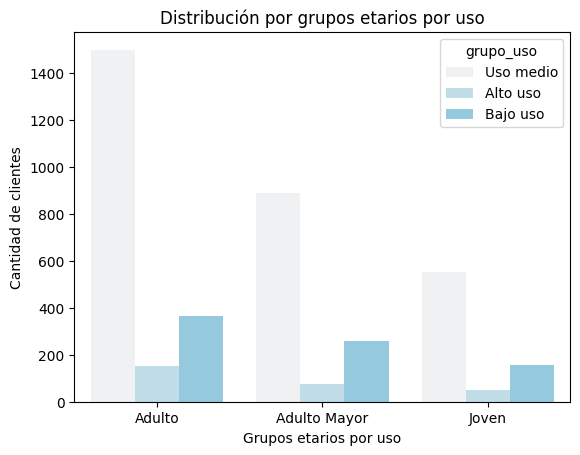

In [46]:
#Se agrega una visualización de planes con edades
sns.countplot(data = user_profile, x = 'grupo_edad',hue = 'grupo_uso', color='skyblue')
plt.xlabel('Grupos etarios por uso')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución por grupos etarios por uso')
plt.show()

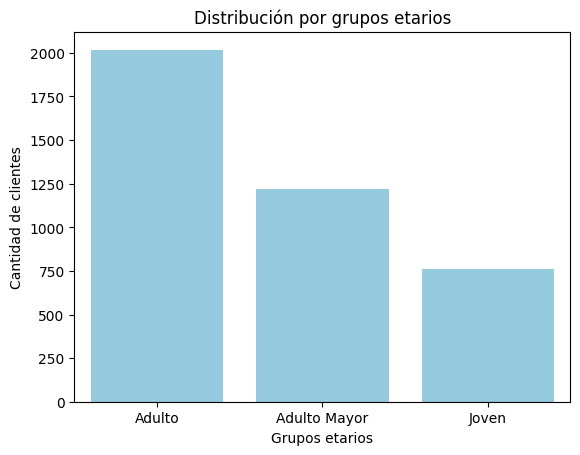

In [43]:

# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x = 'grupo_edad', color='skyblue')
plt.xlabel('Grupos etarios')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución por grupos etarios')
plt.show()


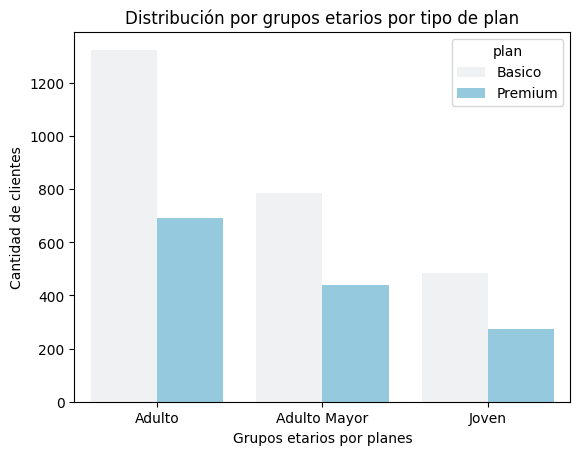

In [45]:
#Se agrega una visualización de planes con edades
sns.countplot(data = user_profile, x = 'grupo_edad',hue = 'plan', color='skyblue')
plt.xlabel('Grupos etarios por planes')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución por grupos etarios por tipo de plan')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos? En general eran datos muy operativos, que estaban por ejemplo en formato distinto, algunos sentinesl y presentaciones distintas a el uso de análisis. Y en la columna churn_date se encontraba casi vacia.

- ¿Qué porcentaje, o cantidad de filas, de esa columna representaban? La columna churn_date estaba en su mayoría vacio con 3534 registros representando el 88.35%, lo cual era extraño, pero a la hora de ver que significaba esto para el negocio, solamente eran las fechas de salida del usuario de la compañia. Lo cual no era relevante para el ejercicio.
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  Que los adultos son los que más usan la compañía en generalen todos los puntos.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? El segmento de adulto, lo cual podría enfocar las campañas de publlicidad a ellos.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
En este caso los outliers son directamente a gastos muy grandes de consumo.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados? Que la publicidad, sin hacer a un lado a los demás segmentos se enfocara a los adultos en edad productiva ya que son los que presentan mucha mayor incidencia y promover que cambien a premium para que sea una mejor ganancia de la compañia, promoviendo o dar una temporada gratuita para ganar adeptos al plan.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Fechas con formatos incorrectos
- Sentinels
- Tratados singulares de datos operativos

🔍 **Segmentos por Edad**
- Joven. Un cliente menor a los 30 años
- Adulto. Un cliente menor a los 60 años
- Adulto mayor. Un cliente que es mayor o igual a los 60 años.

Se observa que en este segmento los que más usan los servicios son los usuarios adultos con cerca del doble de los Adultos mayores, en su mayoría con plan básico y uso medio, lo cual es una tendencia con los distintos grupos etarios.

📊 **Segmentos por Nivel de Uso**
- Bajo. Cuando los usuarios tienen menos de 5 llamadas y menos de 5 mensajes
- Medio. Cuando los usuarios tienen menos de 10 llamadas y menos de 10 mensajes
- Alto. Cuando los usuarios tienen más de los limitantes anteriores.

Se observa una tendencia de uso medio tanto en la distribución etaria como en la de plan.

➡️ Esto sugiere que los planes que mas se venden son los básicos por Adultos y que el plan Premium que es donde más ganancia tiene la compañia es aproximadamente la mitar del basico, y que el uso medio de los servicios es que está presentandose más conforme lo que esta planeado.

💡 **Recomendaciones**
- Tener como objetovo sin dejar atrás los demás grupos etarios a los Adultos, campañas publicitarias enfocadas al movimiento a premium de los Adultos. Dando como otras compañias los precios más económicos el primer mes, entre otros para enganchar a los usuarios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/manuelmichoacan/ConnectaTel